In [1]:
import pandas as pd

In [16]:
df=pd.read_csv(r"/content/students_grades.csv")

In [10]:


df.columns = df.columns.str.strip()


for col in ['FDS', 'DAA', 'MATHS', 'OS']:
    df[col] = df[col].str.strip().str.upper()

grade_points = {
    "A": 90,
    "B": 75,
    "C": 60,
    "D": 50
}


for col in ['FDS', 'DAA', 'MATHS', 'OS']:
    df[col + '_Marks'] = df[col].map(grade_points)


df['Total'] = df[['FDS_Marks', 'DAA_Marks', 'MATHS_Marks', 'OS_Marks']].sum(axis=1)
df['Average'] = df['Total'] / 4


df['Status'] = df[['FDS', 'DAA', 'MATHS', 'OS']].apply(
    lambda x: 'Fail' if 'D' in x.values else 'Pass', axis=1
)


df['Rank'] = df['Total'].rank(ascending=False, method='min')


print(df.tail())



    Student FDS DAA MATHS OS  Unnamed: 6  FDS_Marks  DAA_Marks  MATHS_Marks  \
25       26   B   C     B  B         NaN         75         60           75   
26       27   A   A     C  B         NaN         90         90           60   
27       28   C   B     B  A         NaN         60         75           75   
28       29   B   A     A  B         NaN         75         90           90   
29       30   A   B     B  C         NaN         90         75           75   

    OS_Marks  Total  Average Status  Rank  
25        75    285    71.25   Pass  23.0  
26        75    315    78.75   Pass  10.0  
27        90    300    75.00   Pass  14.0  
28        75    330    82.50   Pass   5.0  
29        60    300    75.00   Pass  14.0  


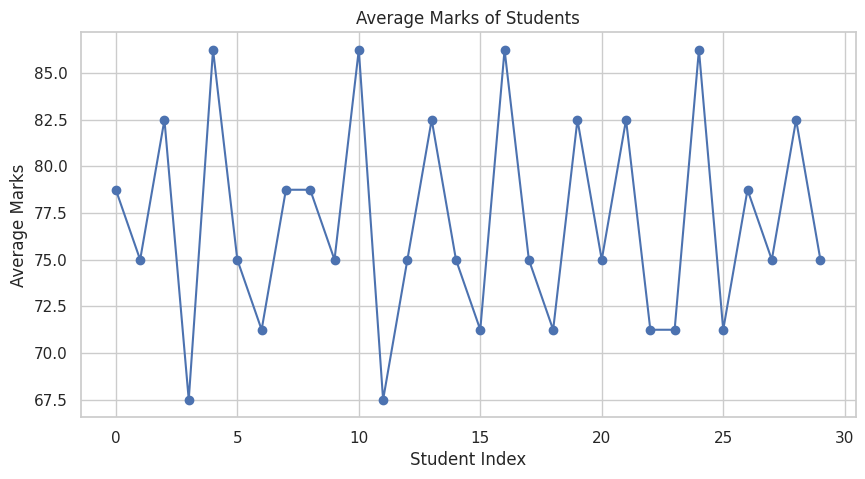

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(10,5))
plt.plot(df['Average'], marker='o')
plt.title("Average Marks of Students")
plt.xlabel("Student Index")
plt.ylabel("Average Marks")
plt.show()

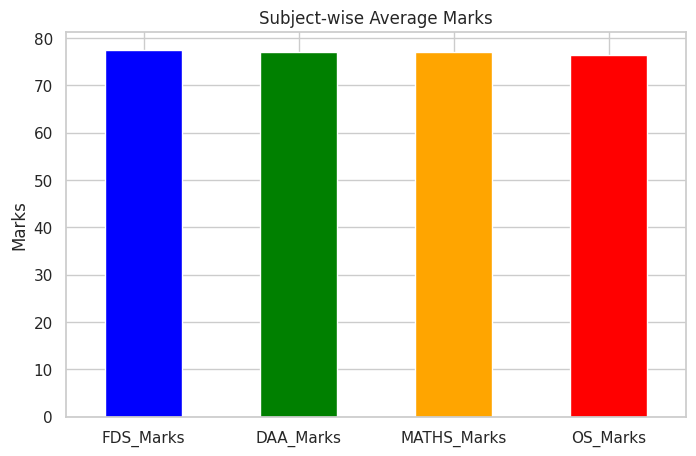

In [12]:
subject_avg = df[['FDS_Marks', 'DAA_Marks', 'MATHS_Marks', 'OS_Marks']].mean()

plt.figure(figsize=(8,5))
subject_avg.plot(kind='bar', color=['blue','green','orange','red'])
plt.title("Subject-wise Average Marks")
plt.ylabel("Marks")
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_395/814394671.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FDS', data=df, palette='cool')


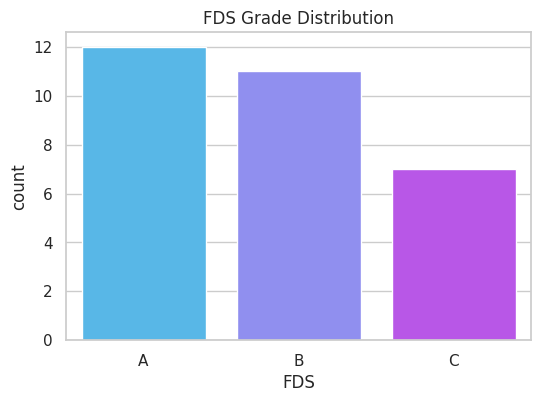

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='FDS', data=df, palette='cool')
plt.title("FDS Grade Distribution")
plt.show()

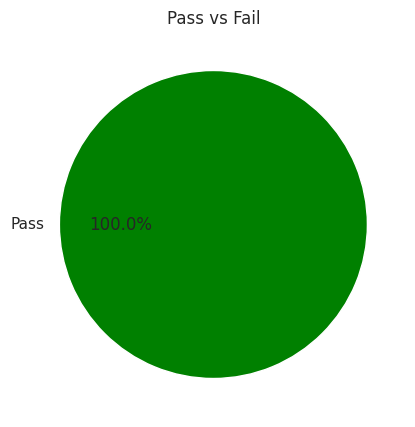

In [14]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['green','red'])
plt.title("Pass vs Fail")
plt.show()


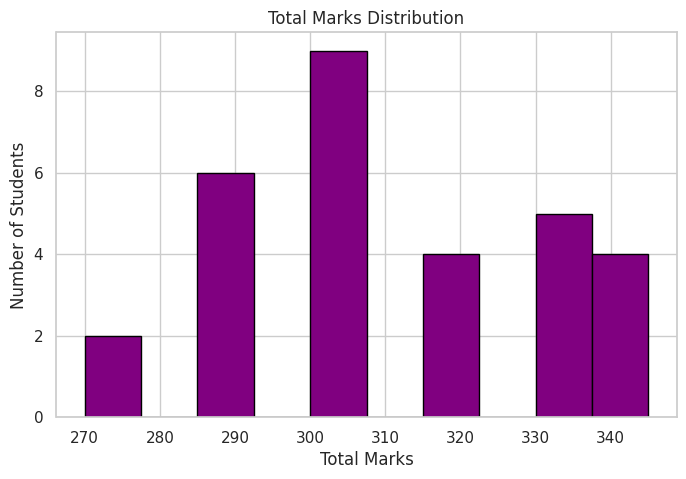

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['Total'], bins=10, color='purple', edgecolor='black')
plt.title("Total Marks Distribution")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.show()